# Laboratorio 3 - 2026

* Brezo, Benjamin
* Veliz, Lautaro
* Reyeros, Marcos

Grupo BandaBase


En este primer punto trabajamos solo con la senal generada en Python, antes de transmitir con el SDR.

## Consigna del punto 1

Realizar una grafica temporal y el histograma de cada una de las componentes de la senal. Realizar tambien una grafica en frecuencia. Describir con palabras propias lo que se observa.

La senal se genera a partir de una hipotesis binaria controlada por `ref`. Luego cada valor se repite `2**4` veces para formar un tren de pulsos.

## Configuracion SDR de referencia

Todavia no se usa el SDR en este punto, pero la consigna indica que luego se trabajara con una configuracion de este estilo:

```python
Uri = "ip:xxx.xxx.x.xx"
SamplingRate = xe6
Loopback = 0
TxLOFreq = xxxe6
TxAtten = -79
TxRfBw = xe6
tx_cyclic_buffer = True
RxLOFreq = TxLOFreq
GainControlModes = "manual"
RxHardwareGain = 70
RxRfBw = TxRfBw
RxBufferSize = len(txSignal)
```

Para el punto 1 solamente necesitamos `SamplingRate`, porque se usa para construir el eje de frecuencia.

## 1. Imports y parametros

Cargamos las librerias y definimos los parametros de la senal generada.

In [7]:
import os

os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib-cache")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.style.use("seaborn-v0_8-whitegrid")

seed = 20260527
rng = np.random.default_rng(seed)

nb_samples = 2**14
samples_per_symbol = 2**4
ref = 0.5

SamplingRate = 1e6

print("Semilla:", seed)
print("Cantidad de hipotesis binarias:", nb_samples)
print("Muestras por hipotesis:", samples_per_symbol)
print("ref:", ref)
print("SamplingRate:", SamplingRate)

Semilla: 20260527
Cantidad de hipotesis binarias: 16384
Muestras por hipotesis: 16
ref: 0.5
SamplingRate: 1000000.0


## 2. Generacion de la senal

Este bloque sigue la idea del codigo de la consigna:

```python
z = np.random.uniform(size=nb_samples)
x = [1 if z[i] > ref else 0 for i in range(len(z))]
txSignal = (2*np.repeat(x, 2**4)-1) + 1j*(2*np.repeat(x, 2**4)-1)
```

La diferencia es que usamos `rng`, que es la forma recomendada por NumPy para generar numeros aleatorios reproducibles.

In [8]:
z = rng.uniform(size=nb_samples)
x = np.array([1 if z_i > ref else 0 for z_i in z])

pulse_train = 2 * np.repeat(x, samples_per_symbol) - 1
txSignal = pulse_train + 1j * pulse_train

print("Primeros 20 valores binarios x:")
print(x[:20])
print("Primeras 40 muestras de txSignal:")
print(txSignal[:40])
print("Longitud de x:", len(x))
print("Longitud de txSignal:", len(txSignal))
print("Valores posibles en I:", np.unique(np.real(txSignal)))
print("Valores posibles en Q:", np.unique(np.imag(txSignal)))

Primeros 20 valores binarios x:
[0 0 1 1 1 0 1 0 1 1 0 1 1 0 1 0 1 1 0 1]
Primeras 40 muestras de txSignal:
[-1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j
 -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j
 -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j
 -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j  1.+1.j  1.+1.j  1.+1.j  1.+1.j
  1.+1.j  1.+1.j  1.+1.j  1.+1.j]
Longitud de x: 16384
Longitud de txSignal: 262144
Valores posibles en I: [-1.  1.]
Valores posibles en Q: [-1.  1.]


## 3. Grafica temporal de I y Q

Separamos la senal compleja en sus componentes:

- `I[n] = real(txSignal[n])`
- `Q[n] = imag(txSignal[n])`

Como I y Q fueron generadas con el mismo tren de pulsos, ambas deberian verse iguales.

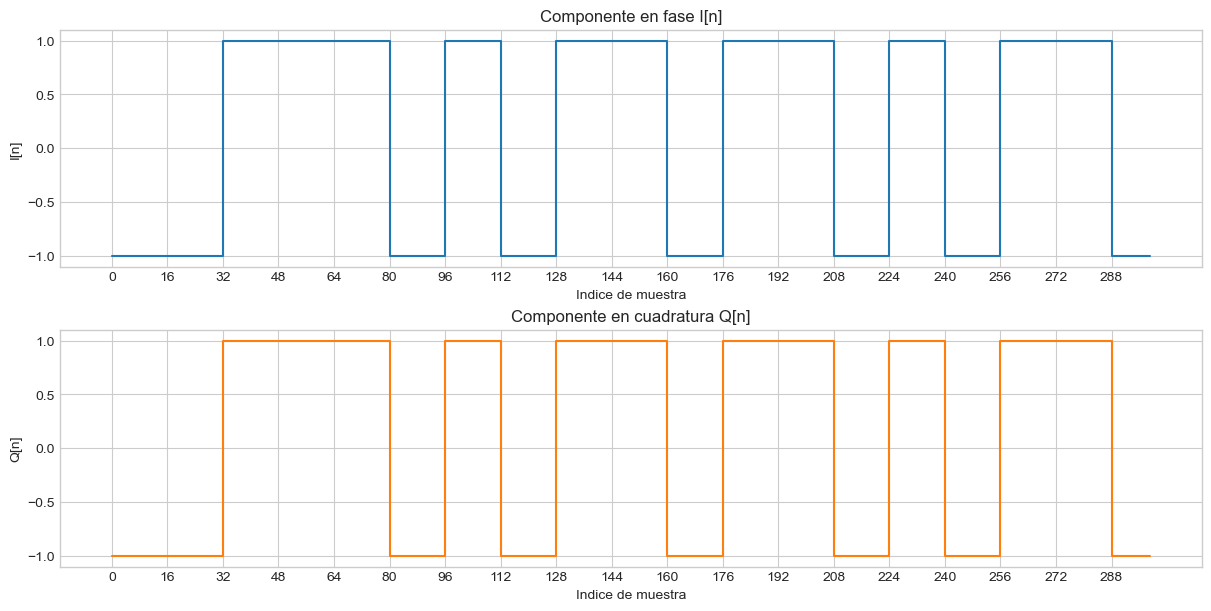

In [9]:
n_preview = 300
n = np.arange(n_preview)

tx_I = np.real(txSignal)
tx_Q = np.imag(txSignal)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].step(n, tx_I[:n_preview], where="post")
axes[0].set_title("Componente en fase I[n]")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I[n]")
axes[0].set_xticks(np.arange(0, n_preview, samples_per_symbol))
axes[0].grid(True)

axes[1].step(n, tx_Q[:n_preview], where="post", color="C1")
axes[1].set_title("Componente en cuadratura Q[n]")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q[n]")
axes[1].set_xticks(np.arange(0, n_preview, samples_per_symbol))
axes[1].grid(True)

plt.show()

## 4. Histogramas de I y Q

El histograma permite ver con que frecuencia aparecen los valores de cada componente. Como `ref = 0.5`, se espera que los niveles `-1` y `+1` aparezcan aproximadamente con la misma frecuencia.

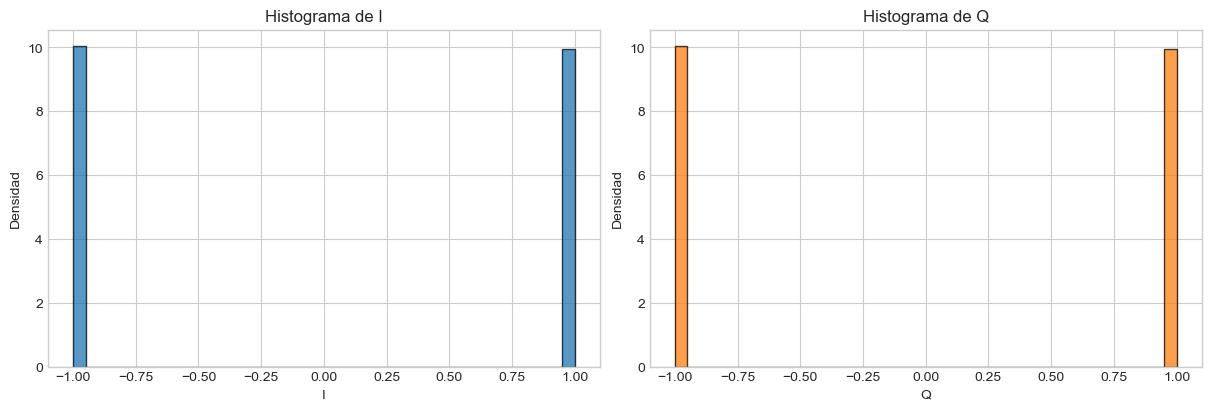

Media de I: -0.0048828125
Media de Q: -0.0048828125
Varianza de I: 0.9999761581420898
Varianza de Q: 0.9999761581420898


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(tx_I, bins=40, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma de I")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(tx_Q, bins=40, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma de Q")
axes[1].set_xlabel("Q")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)

plt.show()

print("Media de I:", np.mean(tx_I))
print("Media de Q:", np.mean(tx_Q))
print("Varianza de I:", np.var(tx_I))
print("Varianza de Q:", np.var(tx_Q))

## 5. Grafica en frecuencia

Estimamos la densidad espectral de potencia usando Welch. Como `txSignal` es compleja, usamos `return_onesided=False` para ver frecuencias positivas y negativas.

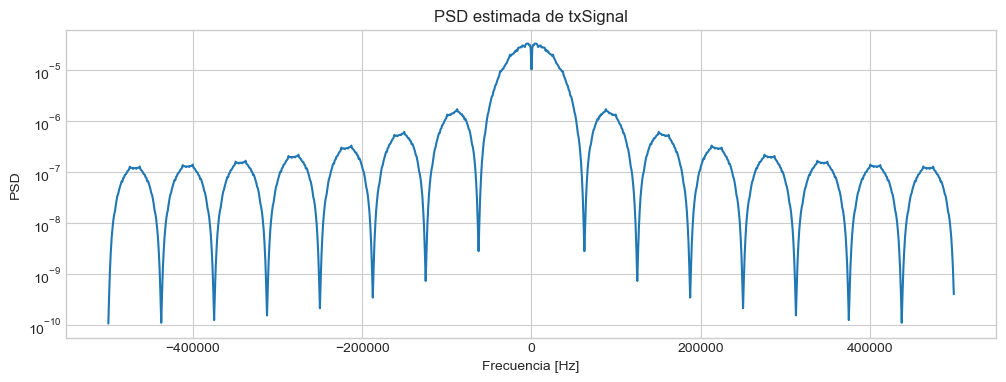

In [11]:
f, Pxx = welch(
    txSignal,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

f_shift = np.fft.fftshift(f)
Pxx_shift = np.fft.fftshift(Pxx)

plt.figure(figsize=(12, 4))
plt.semilogy(f_shift, Pxx_shift)
plt.title("PSD estimada de txSignal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)
plt.show()

## 6. Descripcion de lo observado


- En la grafica temporal se observa que las componentes I y Q toman valores discretos `-1` y `+1`. Cada valor se mantiene durante 16 muestras porque se uso `np.repeat(x, 2**4)`.
- Los histogramas de I y Q presentan dos grupos principales, uno alrededor de `-1` y otro alrededor de `+1`. Como `ref = 0.5`, ambos grupos deberian tener alturas parecidas, en efecto las tienen. Tiene una altura de 10, ya que los histogramas se encuentras normalizados y se estableció un número de intervalos de 40 y como la distancia entre los extremos de los valores observados es 2, esto implica que el ancho de cada intervalo es igual a $\frac{2}{40}=0.05$ lo que lleva a que el área de cada una de las barras del histograma sean el producto de la altura por el ancho ($10*0.05 = 0.5$) y por consiguiente la suma total de las áreas del histograma es $0.5+0.5=1$.

- La grafica en frecuencia muestra como se distribuye la potencia de la senal generada. Al ser un tren de pulsos rectangulares, la senal no concentra toda su energia en una unica frecuencia, sino que presenta contenido espectral distribuido. El espectro presenta la forma de una función sinc al cuadrado, lo que es esperable porque la señal fue construida como un tren de pulsos rectangulares de 16 muestras de duración. La mayor parte de la potencia se encuentra concentrada en el centro, al rededor de $f = 0$. Los lóbulos laterales decaen en amplitud a medida que aumenta la frecuencia. Esto ocurre porque el pulso rectangular tiene flancos abruptos en el tiempo, y esta discontinuidad genera contenido de alta frecuencia.

# Punto 2 - Transmision y recepcion con SDR

En este punto transmitimos `txSignal` usando el SDR, recibimos la senal a traves del medio inalambrico, descartamos varias capturas iniciales para limpiar transitorios y buffers viejos, normalizamos la senal recibida a potencia unitaria y analizamos sus componentes I/Q.

## 7. Configuracion del SDR

Esta celda requiere estar conectado a la VPN y usar el kernel `Python (lab3-sdr)`. Los parametros siguen la estructura de la consigna.

Importante: confirmar la IP real del SDR antes de ejecutar.

In [12]:
import adi

Uri = "ip:192.168.1.32"

Loopback = 0

# Transmitter
TxLOFreq = 2_400_000_000
TxAtten = -79
TxRfBw = int(SamplingRate)
tx_cyclic_buffer = True

# Receiver
RxLOFreq = TxLOFreq
GainControlModes = "manual"
RxHardwareGain = 70
RxRfBw = TxRfBw
RxBufferSize = len(txSignal)

sdr = adi.Pluto(Uri)

sdr.sample_rate = int(SamplingRate)
sdr.loopback = Loopback

sdr.tx_lo = int(TxLOFreq)
sdr.tx_hardwaregain_chan0 = TxAtten
sdr.tx_rf_bandwidth = int(TxRfBw)
sdr.tx_cyclic_buffer = tx_cyclic_buffer

sdr.rx_lo = int(RxLOFreq)
sdr.gain_control_mode_chan0 = GainControlModes
sdr.rx_hardwaregain_chan0 = RxHardwareGain
sdr.rx_rf_bandwidth = int(RxRfBw)
sdr.rx_buffer_size = int(RxBufferSize)

print("SDR conectado en:", Uri)
print("SamplingRate:", sdr.sample_rate)
print("TxLOFreq:", sdr.tx_lo)
print("RxLOFreq:", sdr.rx_lo)
print("TxAtten:", sdr.tx_hardwaregain_chan0)
print("RxHardwareGain:", sdr.rx_hardwaregain_chan0)
print("RxBufferSize:", sdr.rx_buffer_size)

SDR conectado en: ip:192.168.1.32
SamplingRate: 999999
TxLOFreq: 2400000000
RxLOFreq: 2400000000
TxAtten: -79
RxHardwareGain: 70
RxBufferSize: 262144


## 8. Transmision, limpieza de buffer y recepcion

La consigna recomienda transmitir en modo continuo y realizar varias recepciones antes de guardar la captura final. Esto evita analizar muestras tomadas durante un transitorio inicial o datos que hayan quedado en el buffer del receptor.

In [13]:
# ---- Transmitter
sdr.tx_destroy_buffer()
sdr.tx(txSignal * (2**14))

# ---- Clear Rx buffer
for i in range(10):
    raw_data = sdr.rx()

# ---- Receiver
rxSignal = sdr.rx()

print("Longitud de txSignal:", len(txSignal))
print("Longitud de rxSignal:", len(rxSignal))
print("Primeras 10 muestras recibidas:")
print(rxSignal[:10])

Longitud de txSignal: 262144
Longitud de rxSignal: 262144
Primeras 10 muestras recibidas:
[-27.+13.j -33.+16.j  -4. -7.j -14.+16.j   4.+20.j  -4.+16.j -14. -3.j
  22. -4.j  26. +9.j   3. +4.j]


## 9. Normalizacion de potencia

Normalizamos la senal recibida para que su potencia promedio sea igual a 1. Esto permite comparar graficas aunque la ganancia del receptor o la atenuacion del transmisor cambien la escala de amplitud.

In [14]:
rxPower = np.mean(np.abs(rxSignal)**2)
rxSignalNorm = rxSignal / np.sqrt(rxPower)

print("Potencia recibida antes de normalizar:", rxPower)
print("Potencia recibida despues de normalizar:", np.mean(np.abs(rxSignalNorm)**2))

rx_I = np.real(rxSignalNorm)
rx_Q = np.imag(rxSignalNorm)

Potencia recibida antes de normalizar: 809.257007598877
Potencia recibida despues de normalizar: 0.9999999999999998


## 10. Grafica temporal de la senal recibida normalizada

A diferencia del punto 1, ahora la senal paso por el SDR y el medio inalambrico. Por eso no esperamos ver pulsos perfectamente cuadrados.

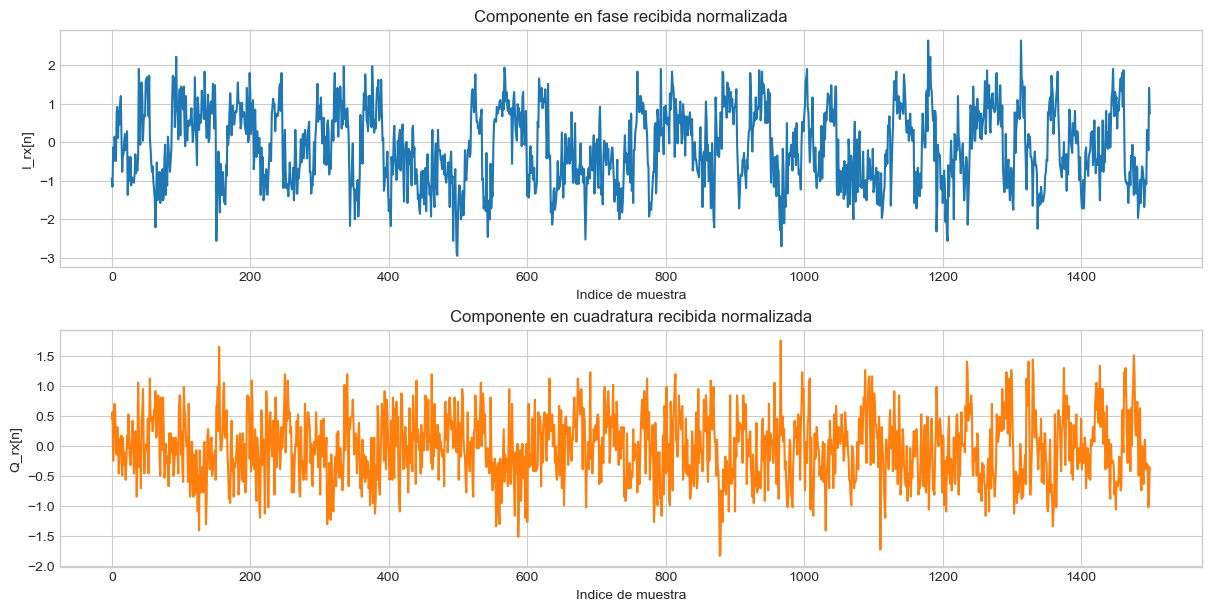

In [15]:
n_preview_rx = 1500
n_rx = np.arange(n_preview_rx)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].plot(n_rx, rx_I[:n_preview_rx])
axes[0].set_title("Componente en fase recibida normalizada")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_rx[n]")
axes[0].grid(True)

axes[1].plot(n_rx, rx_Q[:n_preview_rx], color="C1")
axes[1].set_title("Componente en cuadratura recibida normalizada")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_rx[n]")
axes[1].grid(True)

plt.show()

## 11. Histogramas de la senal recibida normalizada

Los histogramas permiten ver como se distribuyen las muestras recibidas en I y Q despues de pasar por el SDR. Si el canal y la recepcion fueran ideales, los valores estarian muy concentrados alrededor de dos niveles. En la practica pueden aparecer dispersion, desplazamientos y rotaciones.

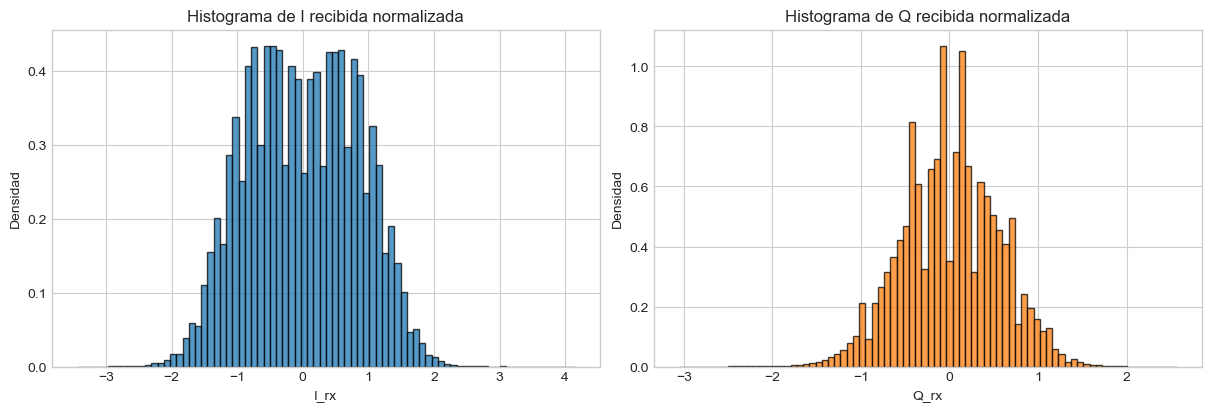

Media de I_rx: -0.002212186909392372
Media de Q_rx: -0.00010781343730081059
Varianza de I_rx: 0.7050606630899915
Varianza de Q_rx: 0.29493443151534904


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rx_I, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma de I recibida normalizada")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rx_Q, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma de Q recibida normalizada")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)

plt.show()

print("Media de I_rx:", np.mean(rx_I))
print("Media de Q_rx:", np.mean(rx_Q))
print("Varianza de I_rx:", np.var(rx_I))
print("Varianza de Q_rx:", np.var(rx_Q))

## 12. Descripcion de lo observado en el punto 2


- En la grafica temporal de la señal recibida se observa que la forma ya no coincide exactamente con los pulsos rectangulares transmitidos. Esto se debe a los efectos del canal, del hardware SDR, del ruido y de posibles desajustes de fase, ganancia o sincronismo.
- La normalizacion hace que la potencia promedio sea unitaria, pero no elimina ruido ni distorsiones.
- En los histogramas de I y Q se observa la distribucion experimental de las muestras recibidas. Se observa que la distribución de las muestras se encuentran solapadas mostrando una única función de densidad de probabilidad Gaussiana, en lugar de dos como se podría esperar en el caso ideal. Esto se puede deber a diferentes factores: ruido, desajueste en fase-frecuencia, respuesta del canal, hardware del SDR y/o sincronismo. Se muestra una distribución continua con forma de campana centrada en 0, con media ≈ 0 y varianza ≈ 0.5 en ambas componentes. Esta diferencia con los histogramas de la señal transmitida se debe a la combinación de dos factores principales. Por un lado, el ruido del canal dispersa cada nivel discreto convirtiéndolo en una distribución gaussiana alrededor de su valor original. Por otro lado, el desajuste de fase y frecuencia entre transmisor y receptor rota la constelación I-Q, mezclando las componentes I y Q entre sí. El resultado es que las dos campanas gaussianas, que en condiciones ideales estarían centradas en -1 y +1, quedan completamente solapadas y centradas en 0, siendo indistinguibles en el histograma.

# Punto 3 - Filtrado con pulso rectangular

La consigna pide filtrar la senal recibida con un pulso rectangular de `2**4` muestras distintas de cero. Como `2**4 = 16`, usamos un filtro con 16 unos.

Este bloque se relaciona con la idea de integrar o acumular la senal durante la duracion de un simbolo.

## 13. Construccion del pulso rectangular y filtrado

El pulso rectangular discreto es un array de 16 muestras iguales a 1. Al filtrar con este pulso, cada salida combina varias muestras vecinas de la senal recibida.

In [17]:
rect_pulse_len = 2**4
rect_pulse = np.ones(rect_pulse_len)

rxSignalFiltered = np.convolve(rxSignalNorm, rect_pulse, mode="same")

rxFiltered_I = np.real(rxSignalFiltered)
rxFiltered_Q = np.imag(rxSignalFiltered)

print("Longitud del pulso rectangular:", len(rect_pulse))
print("Pulso rectangular:", rect_pulse)
print("Longitud de rxSignalNorm:", len(rxSignalNorm))
print("Longitud de rxSignalFiltered:", len(rxSignalFiltered))

Longitud del pulso rectangular: 16
Pulso rectangular: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Longitud de rxSignalNorm: 262144
Longitud de rxSignalFiltered: 262144


## 14. Grafica temporal de la senal filtrada

Se grafican las componentes I y Q luego del filtrado rectangular. La amplitud puede cambiar porque el filtro suma energia durante 16 muestras.

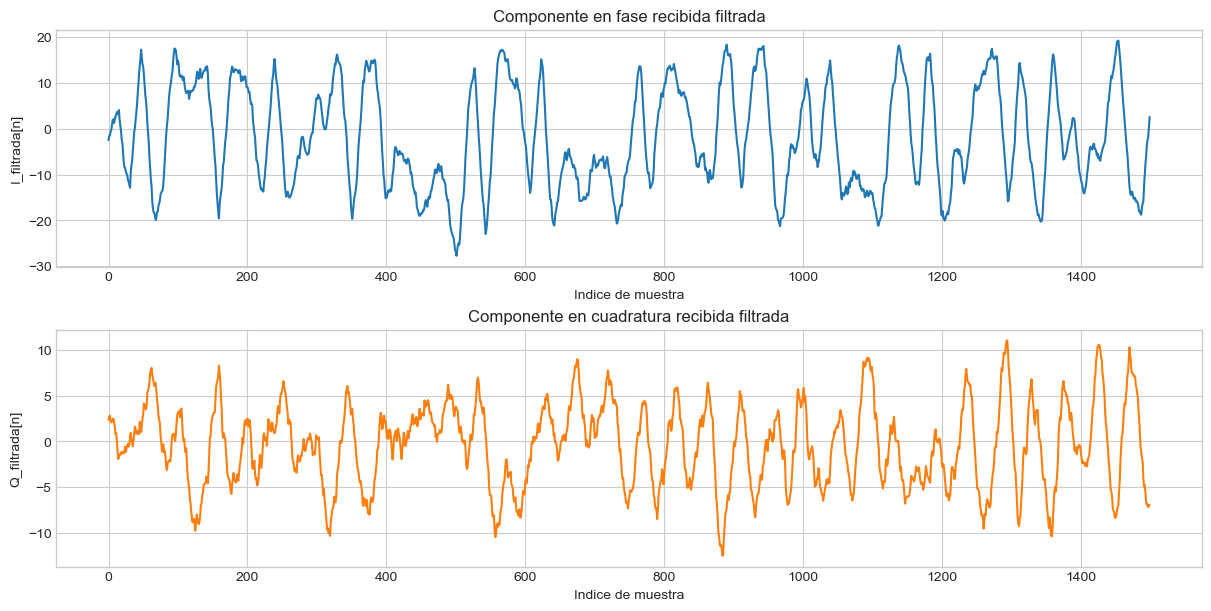

In [18]:
n_preview_filtered = 1500
n_filtered = np.arange(n_preview_filtered)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].plot(n_filtered, rxFiltered_I[:n_preview_filtered])
axes[0].set_title("Componente en fase recibida filtrada")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_filtrada[n]")
axes[0].grid(True)

axes[1].plot(n_filtered, rxFiltered_Q[:n_preview_filtered], color="C1")
axes[1].set_title("Componente en cuadratura recibida filtrada")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_filtrada[n]")
axes[1].grid(True)

plt.show()

## 15. Histogramas de la senal filtrada

El histograma luego del filtrado permite observar si la acumulacion sobre 16 muestras ayuda a separar mejor los niveles recibidos o si la dispersion del canal sigue mezclandolos.

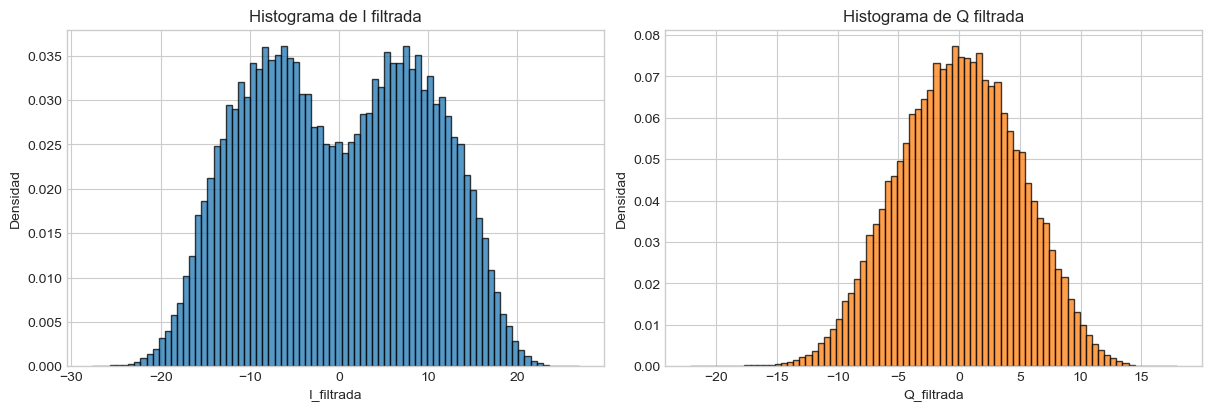

Media de I filtrada: -0.035252848456324135
Media de Q filtrada: -0.0016812995981064227
Varianza de I filtrada: 95.03425608956834
Varianza de Q filtrada: 24.742985291244324


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rxFiltered_I, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma de I filtrada")
axes[0].set_xlabel("I_filtrada")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rxFiltered_Q, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma de Q filtrada")
axes[1].set_xlabel("Q_filtrada")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)

plt.show()

print("Media de I filtrada:", np.mean(rxFiltered_I))
print("Media de Q filtrada:", np.mean(rxFiltered_Q))
print("Varianza de I filtrada:", np.var(rxFiltered_I))
print("Varianza de Q filtrada:", np.var(rxFiltered_Q))

## 16. Descripcion de lo observado en el punto 3

- El filtrado con pulso rectangular de 16 muestras acumula la senal recibida durante una ventana equivalente a la duracion de un simbolo.
- En la grafica temporal puede observarse una senal mas suavizada o con amplitudes mayores, porque el filtro suma muestras consecutivas.
- Revisando los histogramas generados vemos que aunque el filtro mejora la SNR, *no corrige la rotación de fase*. Las muestras siguen siendo una mezcla de I y Q rotadas, entonces el filtro promedia esa mezcla y el resultado sigue centrado en 0 con distribución gaussiana. La forma de campana se ve incluso más limpia y simétrica que antes, precisamente porque el filtro suavizó el ruido.

# Punto 4 - Aumento de potencia transmitida

La consigna pide repetir los pasos anteriores aumentando la potencia de la senal transmitida. Para eso se cambia `TxAtten` de `-79` a `-70`.

En este SDR, un valor menos negativo implica menor atenuacion en transmision. Por lo tanto, `TxAtten = -70` transmite con mas potencia que `TxAtten = -79`.

## 17. Retransmision con `TxAtten = -70`

Se vuelve a transmitir la misma senal `txSignal`, pero con mayor potencia. Igual que antes, se descartan varias recepciones iniciales para evitar transitorios y limpiar el buffer del receptor.

In [20]:
TxAtten_high_power = -70

sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = TxAtten_high_power
sdr.tx(txSignal * (2**14))

for i in range(10):
    raw_data_high_power = sdr.rx()

rxSignalHighPower = sdr.rx()

print("TxAtten anterior:", TxAtten)
print("TxAtten nuevo:", sdr.tx_hardwaregain_chan0)
print("Longitud de rxSignalHighPower:", len(rxSignalHighPower))
print("Primeras 10 muestras recibidas con mayor potencia:")
print(rxSignalHighPower[:10])

TxAtten anterior: -79
TxAtten nuevo: -70
Longitud de rxSignalHighPower: 262144
Primeras 10 muestras recibidas con mayor potencia:
[58.-14.j 44.-67.j 37.-65.j 35.-49.j 44.-49.j 76.-38.j 60.-11.j 36. -8.j
 67.-30.j 59.-35.j]


## 18. Normalizacion y grafica temporal con mayor potencia

Se normaliza la nueva recepcion a potencia unitaria para comparar la forma y la distribucion de las muestras sin que la escala absoluta tape el analisis.

Potencia antes de normalizar con TxAtten = -70: 3292.191230773926
Potencia despues de normalizar con TxAtten = -70: 0.9999999999999999


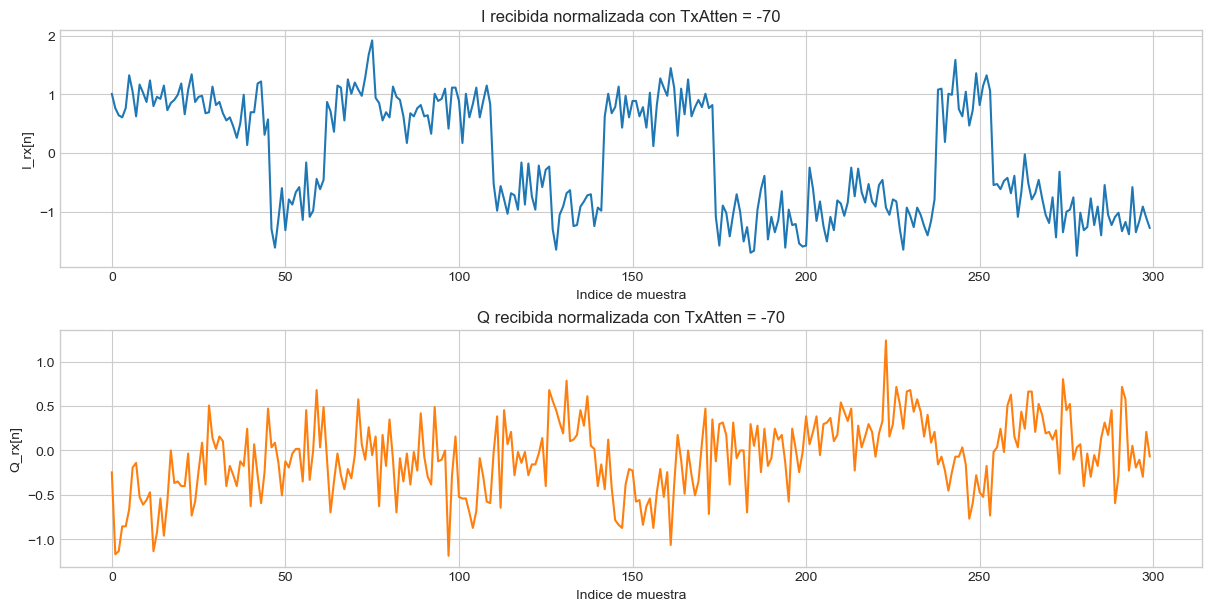

In [21]:
rxPowerHigh = np.mean(np.abs(rxSignalHighPower)**2)
rxSignalHighPowerNorm = rxSignalHighPower / np.sqrt(rxPowerHigh)

rxHigh_I = np.real(rxSignalHighPowerNorm)
rxHigh_Q = np.imag(rxSignalHighPowerNorm)

print("Potencia antes de normalizar con TxAtten = -70:", rxPowerHigh)
print("Potencia despues de normalizar con TxAtten = -70:", np.mean(np.abs(rxSignalHighPowerNorm)**2))

n_preview_high = 300
n_high = np.arange(n_preview_high)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].plot(n_high, rxHigh_I[:n_preview_high])
axes[0].set_title("I recibida normalizada con TxAtten = -70")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_rx[n]")
axes[0].grid(True)

axes[1].plot(n_high, rxHigh_Q[:n_preview_high], color="C1")
axes[1].set_title("Q recibida normalizada con TxAtten = -70")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_rx[n]")
axes[1].grid(True)

plt.show()

## 19. Histogramas con mayor potencia y comparacion

Primero se grafican los histogramas de la nueva recepcion normalizada. Luego se superponen con los histogramas obtenidos anteriormente con `TxAtten = -79` para comparar la dispersion.

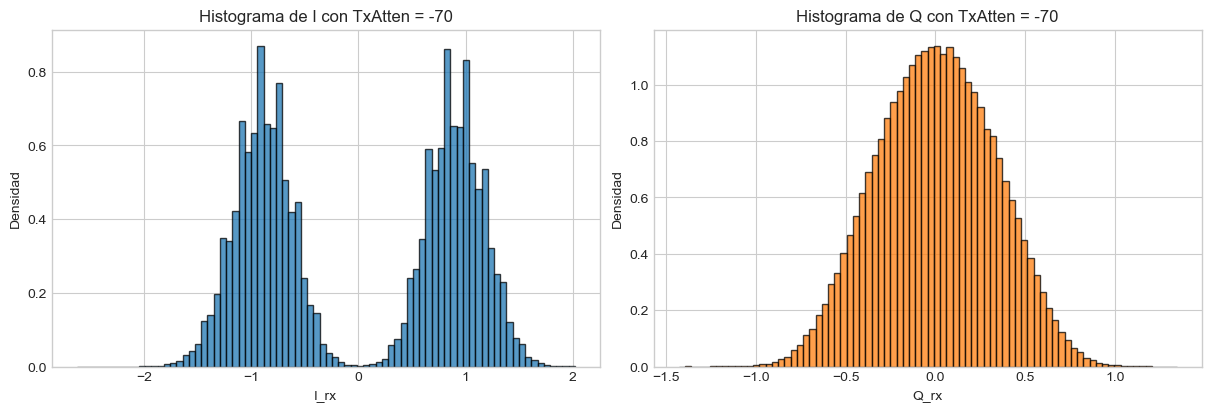

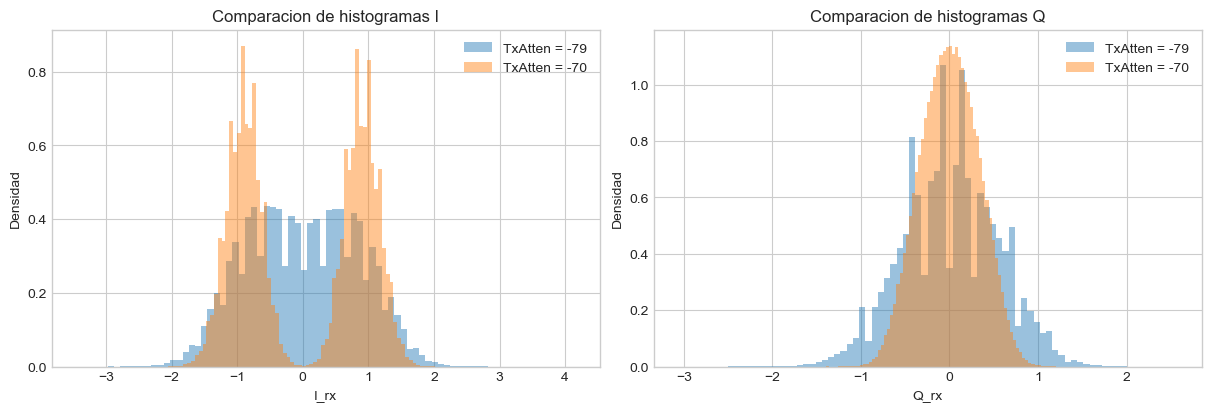

Media I con TxAtten = -70: 0.0008285243908162889
Media Q con TxAtten = -70: 0.0029984312330135357
Varianza I con TxAtten = -70: 0.8909798302924081
Varianza Q con TxAtten = -70: 0.10901049266506653


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rxHigh_I, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma de I con TxAtten = -70")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rxHigh_Q, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma de Q con TxAtten = -70")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rx_I, bins=80, density=True, alpha=0.45, label="TxAtten = -79")
axes[0].hist(rxHigh_I, bins=80, density=True, alpha=0.45, label="TxAtten = -70")
axes[0].set_title("Comparacion de histogramas I")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(rx_Q, bins=80, density=True, alpha=0.45, label="TxAtten = -79")
axes[1].hist(rxHigh_Q, bins=80, density=True, alpha=0.45, label="TxAtten = -70")
axes[1].set_title("Comparacion de histogramas Q")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(True)

plt.show()

print("Media I con TxAtten = -70:", np.mean(rxHigh_I))
print("Media Q con TxAtten = -70:", np.mean(rxHigh_Q))
print("Varianza I con TxAtten = -70:", np.var(rxHigh_I))
print("Varianza Q con TxAtten = -70:", np.var(rxHigh_Q))

## 20. PSD con mayor potencia y comparacion

Como el punto 4 pide repetir los pasos anteriores, tambien estimamos la PSD de la senal recibida con `TxAtten = -70` y la comparamos con la PSD del caso anterior.

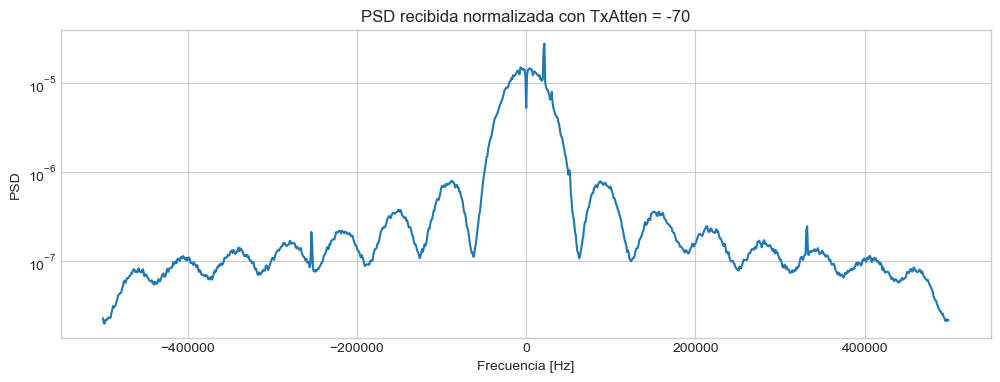

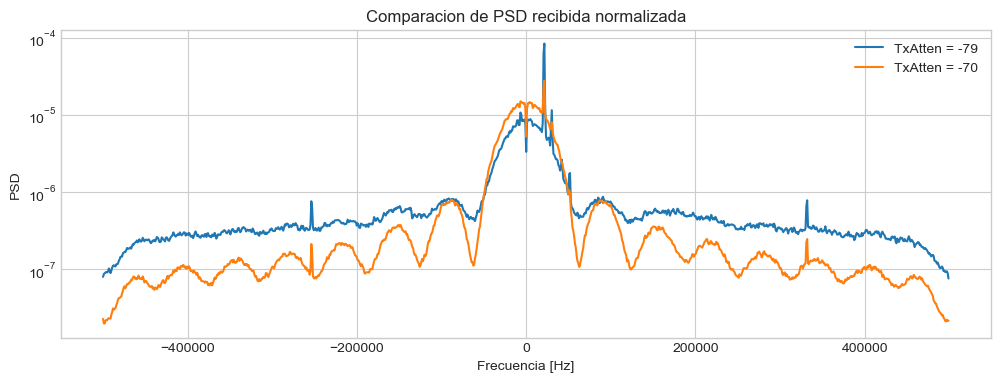

In [23]:
f_rx, Pxx_rx = welch(
    rxSignalNorm,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

f_high, Pxx_high = welch(
    rxSignalHighPowerNorm,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

f_rx_shift = np.fft.fftshift(f_rx)
Pxx_rx_shift = np.fft.fftshift(Pxx_rx)
f_high_shift = np.fft.fftshift(f_high)
Pxx_high_shift = np.fft.fftshift(Pxx_high)

plt.figure(figsize=(12, 4))
plt.semilogy(f_high_shift, Pxx_high_shift)
plt.title("PSD recibida normalizada con TxAtten = -70")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.semilogy(f_rx_shift, Pxx_rx_shift, label="TxAtten = -79")
plt.semilogy(f_high_shift, Pxx_high_shift, label="TxAtten = -70")
plt.title("Comparacion de PSD recibida normalizada")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.grid(True)
plt.show()

## 21. Filtrado rectangular con mayor potencia

Para repetir tambien el filtrado del punto 3, aplicamos el mismo pulso rectangular de 16 muestras sobre la senal recibida con `TxAtten = -70`.

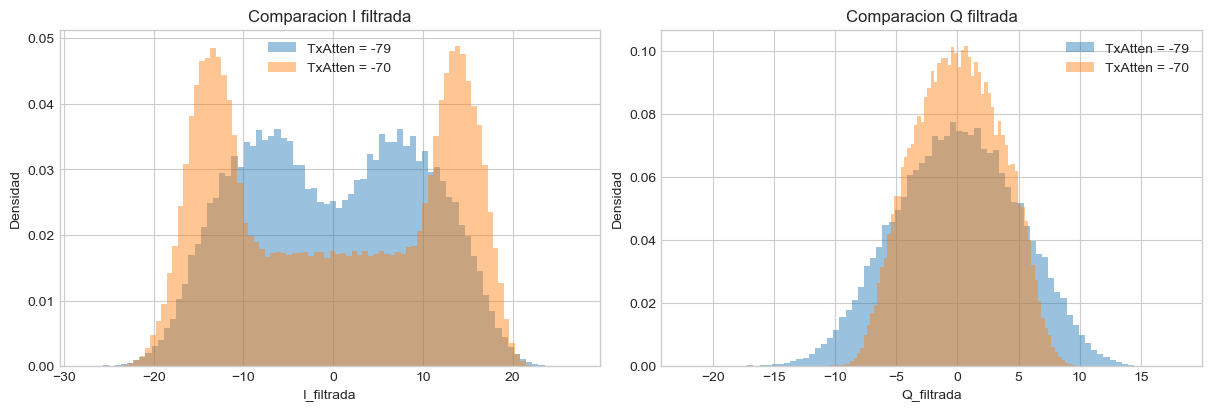

In [24]:
rxSignalHighPowerFiltered = np.convolve(rxSignalHighPowerNorm, rect_pulse, mode="same")

rxHighFiltered_I = np.real(rxSignalHighPowerFiltered)
rxHighFiltered_Q = np.imag(rxSignalHighPowerFiltered)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rxFiltered_I, bins=80, density=True, alpha=0.45, label="TxAtten = -79")
axes[0].hist(rxHighFiltered_I, bins=80, density=True, alpha=0.45, label="TxAtten = -70")
axes[0].set_title("Comparacion I filtrada")
axes[0].set_xlabel("I_filtrada")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(rxFiltered_Q, bins=80, density=True, alpha=0.45, label="TxAtten = -79")
axes[1].hist(rxHighFiltered_Q, bins=80, density=True, alpha=0.45, label="TxAtten = -70")
axes[1].set_title("Comparacion Q filtrada")
axes[1].set_xlabel("Q_filtrada")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(True)

plt.show()

## 22. PSD de la senal filtrada con mayor potencia

Tambien comparamos en frecuencia las senales filtradas de ambos casos.

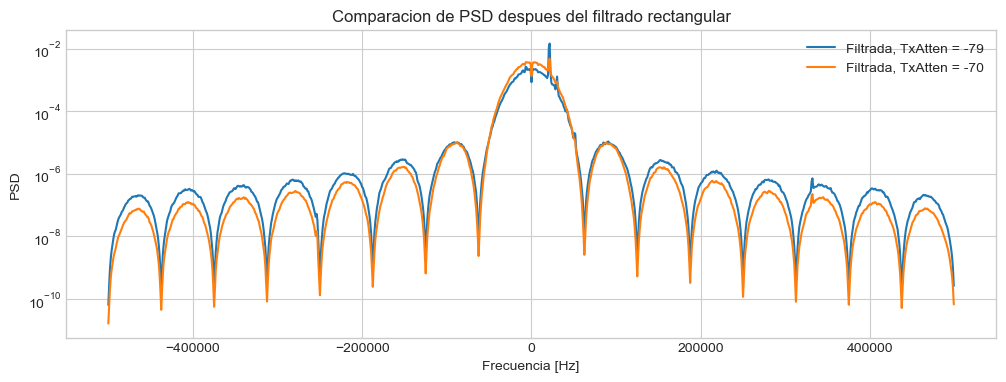

In [25]:
f_filt, Pxx_filt = welch(
    rxSignalFiltered,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

f_high_filt, Pxx_high_filt = welch(
    rxSignalHighPowerFiltered,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

plt.figure(figsize=(12, 4))
plt.semilogy(np.fft.fftshift(f_filt), np.fft.fftshift(Pxx_filt), label="Filtrada, TxAtten = -79")
plt.semilogy(np.fft.fftshift(f_high_filt), np.fft.fftshift(Pxx_high_filt), label="Filtrada, TxAtten = -70")
plt.title("Comparacion de PSD despues del filtrado rectangular")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.grid(True)
plt.show()

## 23. Descripcion de lo observado en el punto 4

- Al cambiar `TxAtten` de `-79` a `-70`, se reduce la atenuacion de transmision y aumenta la potencia enviada por el SDR.
- Como la transmisión mejora, los histogramas se muestran en grupos más difinidos con respecto al punto anterior.
- Aunque la senal se normaliza a potencia unitaria, la mayor potencia transmitida puede mejorar la relacion señal-ruido antes de normalizar. Por eso la forma del histograma puede cambiar.
- Si con `TxAtten = -79` el histograma se parecia mas a una sola campana alrededor de cero y con `TxAtten = -70` aparecen dos campanas alrededor de niveles positivos y negativos, eso indica que al aumentar la potencia transmitida los simbolos comienzan a distinguirse mejor respecto del ruido.
- En frecuencia, la PSD permite comparar como se distribuye la potencia recibida antes y despues de aumentar la potencia transmitida. Como las senales estan normalizadas, la comparacion no debe interpretarse solo como amplitud absoluta, sino tambien como forma espectral y presencia relativa de ruido. 

# Punto 5 - Repeticion con `ref = 0.3`

Ahora repetimos el experimento cambiando la probabilidad de ocurrencia de las hipotesis binarias. Con `ref = 0.3`, la regla `x = 1 if z > ref else 0` hace que el valor `1` sea mas probable que el valor `0`.

En teoria, si `z` es uniforme entre 0 y 1:

- `P(x = 0) = P(z <= 0.3) = 0.3`
- `P(x = 1) = P(z > 0.3) = 0.7`

Entonces, despues del mapeo `0 -> -1` y `1 -> +1`, se espera que haya mas muestras positivas que negativas.

## 24. Generacion de la senal con `ref = 0.3`

Se genera una nueva senal `txSignal_ref03` usando la misma estructura del punto 1, pero con `ref = 0.3`.

In [26]:
ref_03 = 0.3

z_ref03 = rng.uniform(size=nb_samples)
x_ref03 = np.array([1 if z_i > ref_03 else 0 for z_i in z_ref03])

pulse_train_ref03 = 2 * np.repeat(x_ref03, samples_per_symbol) - 1
txSignal_ref03 = pulse_train_ref03 + 1j * pulse_train_ref03

print("ref usado:", ref_03)
print("Fraccion de ceros:", np.mean(x_ref03 == 0))
print("Fraccion de unos:", np.mean(x_ref03 == 1))
print("Longitud de txSignal_ref03:", len(txSignal_ref03))
print("Valores posibles en I:", np.unique(np.real(txSignal_ref03)))
print("Valores posibles en Q:", np.unique(np.imag(txSignal_ref03)))

ref usado: 0.3
Fraccion de ceros: 0.30096435546875
Fraccion de unos: 0.69903564453125
Longitud de txSignal_ref03: 262144
Valores posibles en I: [-1.  1.]
Valores posibles en Q: [-1.  1.]


## 25. Analisis local de la senal con `ref = 0.3`

Antes de transmitir, miramos tiempo, histogramas y PSD de la senal generada. El cambio mas importante deberia aparecer en los histogramas: el nivel `+1` deberia tener mayor peso que el nivel `-1`.

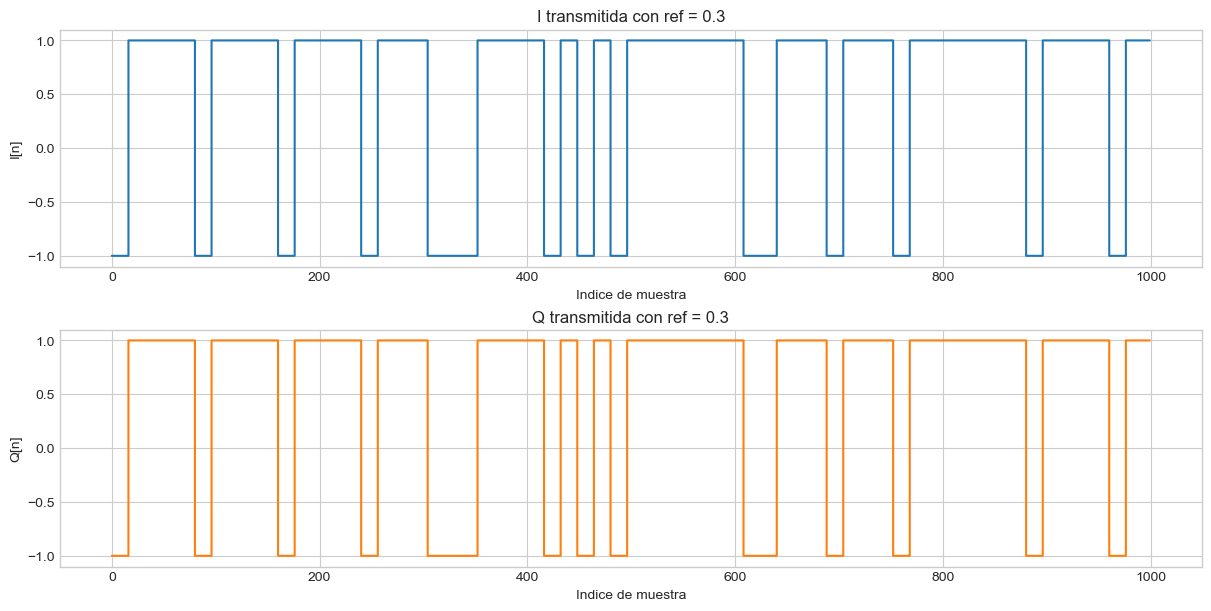

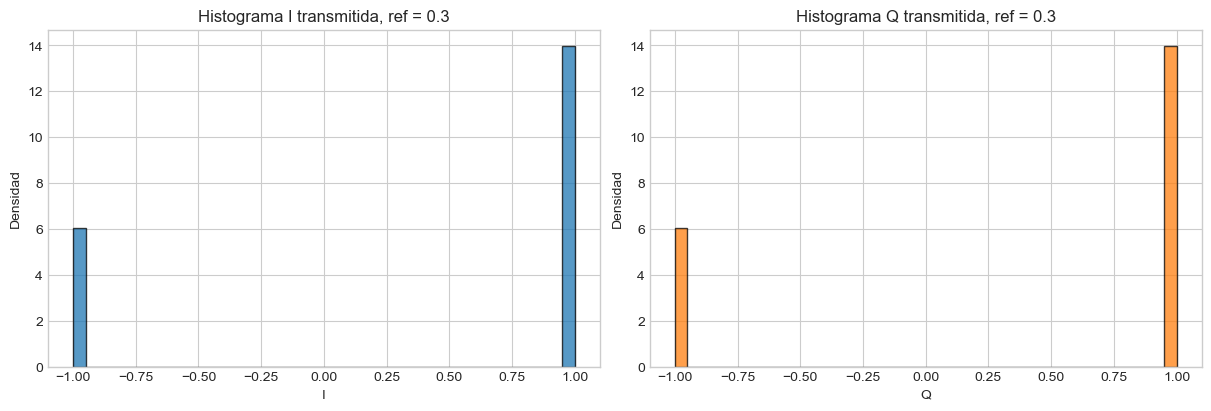

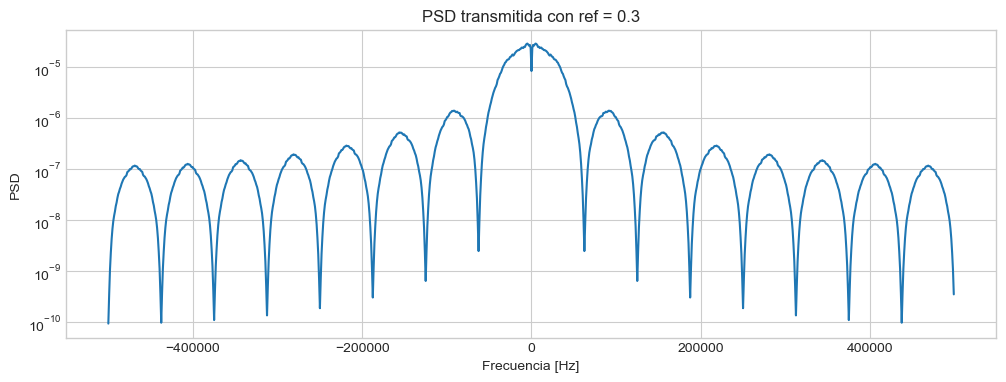

In [27]:
tx_I_ref03 = np.real(txSignal_ref03)
tx_Q_ref03 = np.imag(txSignal_ref03)

n_preview_ref03 = 1000
n_ref03 = np.arange(n_preview_ref03)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].step(n_ref03, tx_I_ref03[:n_preview_ref03], where="post")
axes[0].set_title("I transmitida con ref = 0.3")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I[n]")
axes[0].grid(True)

axes[1].step(n_ref03, tx_Q_ref03[:n_preview_ref03], where="post", color="C1")
axes[1].set_title("Q transmitida con ref = 0.3")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q[n]")
axes[1].grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(tx_I_ref03, bins=40, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma I transmitida, ref = 0.3")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(tx_Q_ref03, bins=40, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma Q transmitida, ref = 0.3")
axes[1].set_xlabel("Q")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)
plt.show()

f_ref03, Pxx_ref03 = welch(
    txSignal_ref03,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

plt.figure(figsize=(12, 4))
plt.semilogy(np.fft.fftshift(f_ref03), np.fft.fftshift(Pxx_ref03))
plt.title("PSD transmitida con ref = 0.3")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)
plt.show()

## 26. Transmision y recepcion con `ref = 0.3`

Se transmite la nueva senal usando la misma configuracion de mayor potencia del punto 4 (`TxAtten = -70`). Luego se limpian buffers y se toma la captura final.

In [28]:
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = TxAtten_high_power
sdr.rx_buffer_size = len(txSignal_ref03)
sdr.tx(txSignal_ref03 * (2**14))

for i in range(10):
    raw_data_ref03 = sdr.rx()

rxSignal_ref03 = sdr.rx()

print("TxAtten usado:", sdr.tx_hardwaregain_chan0)
print("Longitud de rxSignal_ref03:", len(rxSignal_ref03))
print("Primeras 10 muestras recibidas:")
print(rxSignal_ref03[:10])

TxAtten usado: -70
Longitud de rxSignal_ref03: 262144
Primeras 10 muestras recibidas:
[56. -1.j 40. +0.j 38. -4.j 48. +8.j 38.-15.j 44.-18.j 50. -7.j 73.-16.j
 49. -1.j 24. -8.j]


## 27. Normalizacion y graficas de la senal recibida con `ref = 0.3`

Normalizamos a potencia unitaria y graficamos las componentes I/Q recibidas.

Potencia antes de normalizar: 2773.9670906066895
Potencia despues de normalizar: 0.9999999999999998


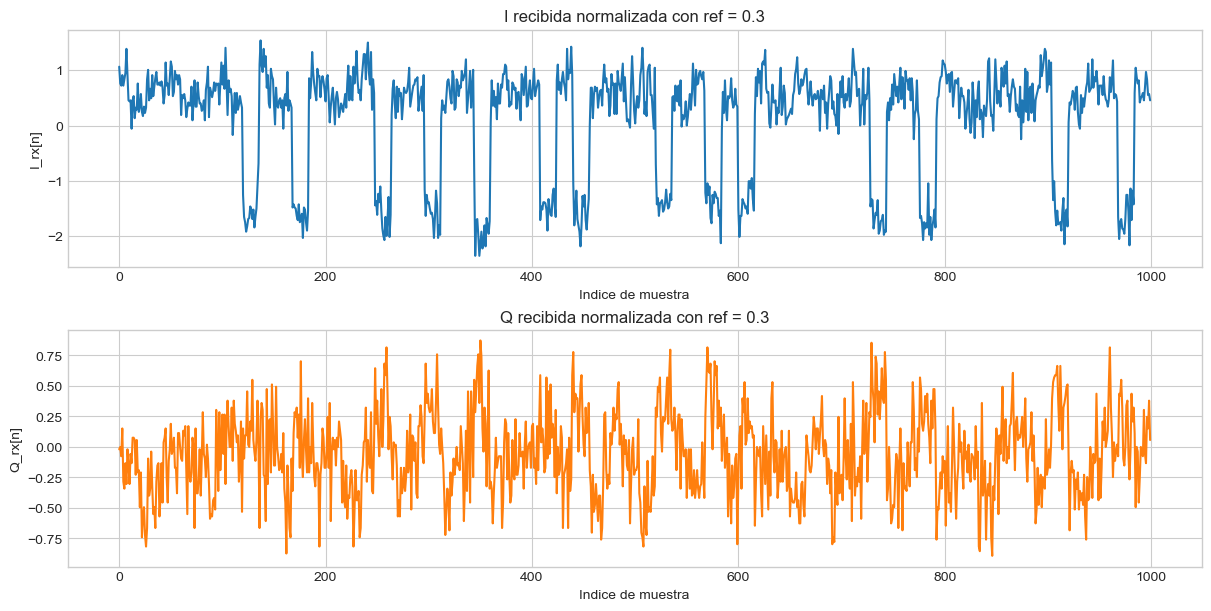

In [29]:
rxPower_ref03 = np.mean(np.abs(rxSignal_ref03)**2)
rxSignalNorm_ref03 = rxSignal_ref03 / np.sqrt(rxPower_ref03)

rx_I_ref03 = np.real(rxSignalNorm_ref03)
rx_Q_ref03 = np.imag(rxSignalNorm_ref03)

print("Potencia antes de normalizar:", rxPower_ref03)
print("Potencia despues de normalizar:", np.mean(np.abs(rxSignalNorm_ref03)**2))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].plot(n_ref03, rx_I_ref03[:n_preview_ref03])
axes[0].set_title("I recibida normalizada con ref = 0.3")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_rx[n]")
axes[0].grid(True)

axes[1].plot(n_ref03, rx_Q_ref03[:n_preview_ref03], color="C1")
axes[1].set_title("Q recibida normalizada con ref = 0.3")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_rx[n]")
axes[1].grid(True)
plt.show()

## 28. Histogramas recibidos con `ref = 0.3` y comparacion

El objetivo principal del punto 5 es observar como cambia el histograma de la senal recibida cuando las hipotesis dejan de ser equiprobables.

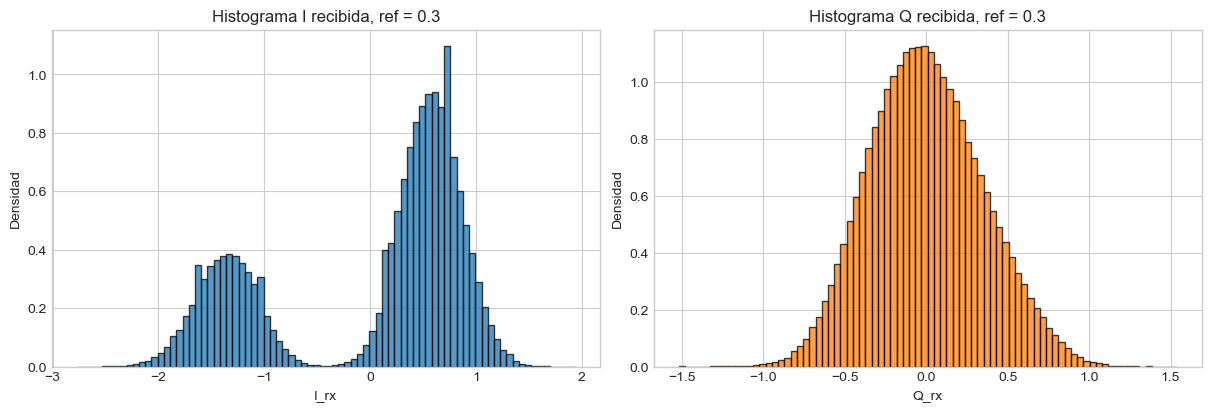

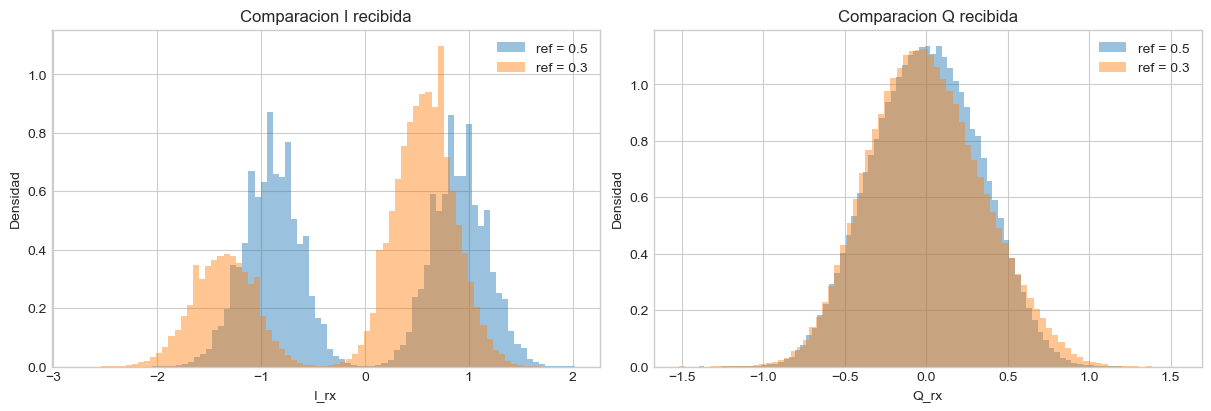

Media I recibida con ref = 0.3: -0.002020392704200829
Media Q recibida con ref = 0.3: 0.0007489105775743529
Varianza I recibida con ref = 0.3: 0.880145924415666
Varianza Q recibida con ref = 0.3: 0.11984943273060142


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(rx_I_ref03, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma I recibida, ref = 0.3")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rx_Q_ref03, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma Q recibida, ref = 0.3")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(rxHigh_I, bins=80, density=True, alpha=0.45, label="ref = 0.5")
axes[0].hist(rx_I_ref03, bins=80, density=True, alpha=0.45, label="ref = 0.3")
axes[0].set_title("Comparacion I recibida")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(rxHigh_Q, bins=80, density=True, alpha=0.45, label="ref = 0.5")
axes[1].hist(rx_Q_ref03, bins=80, density=True, alpha=0.45, label="ref = 0.3")
axes[1].set_title("Comparacion Q recibida")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(True)
plt.show()

print("Media I recibida con ref = 0.3:", np.mean(rx_I_ref03))
print("Media Q recibida con ref = 0.3:", np.mean(rx_Q_ref03))
print("Varianza I recibida con ref = 0.3:", np.var(rx_I_ref03))
print("Varianza Q recibida con ref = 0.3:", np.var(rx_Q_ref03))

## 29. PSD recibida con `ref = 0.3`

Tambien observamos la distribucion espectral de la senal recibida para mantener la comparacion con los puntos anteriores.

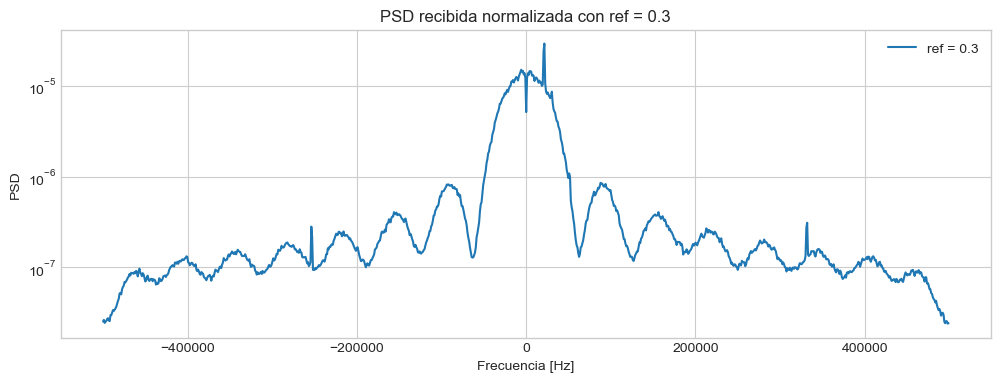

In [31]:
f_rx_ref03, Pxx_rx_ref03 = welch(
    rxSignalNorm_ref03,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

plt.figure(figsize=(12, 4))
plt.semilogy(np.fft.fftshift(f_rx_ref03), np.fft.fftshift(Pxx_rx_ref03), label="ref = 0.3")
plt.title("PSD recibida normalizada con ref = 0.3")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.grid(True)
plt.show()

## 30. Filtrado rectangular con `ref = 0.3`

Repetimos el filtrado rectangular de 16 muestras para observar la distribucion luego de acumular energia durante una ventana de simbolo.

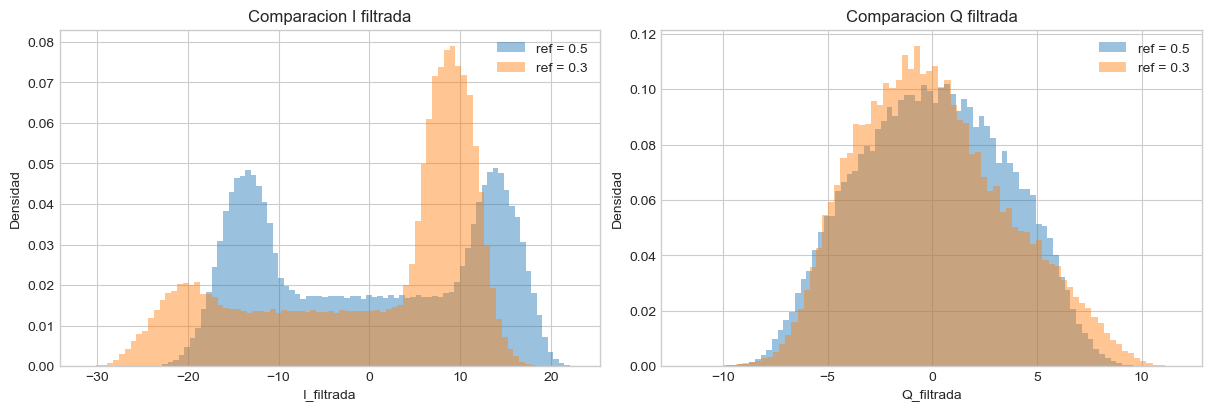

In [32]:
rxSignalFiltered_ref03 = np.convolve(rxSignalNorm_ref03, rect_pulse, mode="same")

rxFiltered_I_ref03 = np.real(rxSignalFiltered_ref03)
rxFiltered_Q_ref03 = np.imag(rxSignalFiltered_ref03)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(rxHighFiltered_I, bins=80, density=True, alpha=0.45, label="ref = 0.5")
axes[0].hist(rxFiltered_I_ref03, bins=80, density=True, alpha=0.45, label="ref = 0.3")
axes[0].set_title("Comparacion I filtrada")
axes[0].set_xlabel("I_filtrada")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(rxHighFiltered_Q, bins=80, density=True, alpha=0.45, label="ref = 0.5")
axes[1].hist(rxFiltered_Q_ref03, bins=80, density=True, alpha=0.45, label="ref = 0.3")
axes[1].set_title("Comparacion Q filtrada")
axes[1].set_xlabel("Q_filtrada")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(True)
plt.show()

## 31. Conclusion del punto 5

- Al usar `ref = 0.3`, la hipotesis `1` ocurre con mayor probabilidad que la hipotesis `0`.
- Como el mapeo usado es `0 -> -1` y `1 -> +1`, se espera que el histograma tenga mayor peso del lado positivo. En efecto esto es lo que ocurre.
- En la senal recibida, el canal y el ruido ensanchan los grupos, pero se sigue observando una asimetria entre los niveles.
- A diferencia de `ref = 0.5`, donde los dos grupos tenian pesos similares, con `ref = 0.3` el histograma deja de ser balanceado. Esto muestra que el histograma no solo refleja el ruido del canal, sino tambien las probabilidades de ocurrencia de las hipotesis transmitidas.

# Punto 6 - Hipotesis multinivel equiprobable

Ahora modificamos la senal transmitida para que la hipotesis pertenezca al conjunto:

```text
H = {-1, -0.3333, +0.3333, +1}
```

con igual probabilidad para cada valor. El objetivo principal de este punto es observar el histograma de la senal recibida por el SDR y describir si aparecen cuatro niveles distinguibles o si el canal/ruido los mezcla.

## 32. Generacion de hipotesis multinivel equiprobable

Elegimos aleatoriamente entre los cuatro niveles con la misma probabilidad. Luego repetimos cada valor `2**4` veces para mantener la misma duracion de simbolo que en los puntos anteriores.

In [33]:
levels = np.array([-1.0, -0.3333, 0.3333, 1.0])

indices_multilevel = rng.integers(0, len(levels), size=nb_samples)
h_multilevel = levels[indices_multilevel]

pulse_train_multilevel = np.repeat(h_multilevel, samples_per_symbol)
txSignal_multilevel = pulse_train_multilevel + 1j * pulse_train_multilevel

print("Niveles posibles:", levels)
print("Primeras 20 hipotesis multinivel:")
print(h_multilevel[:20])
print("Longitud de h_multilevel:", len(h_multilevel))
print("Longitud de txSignal_multilevel:", len(txSignal_multilevel))

for level in levels:
    print(f"Fraccion de nivel {level}:", np.mean(h_multilevel == level))

Niveles posibles: [-1.     -0.3333  0.3333  1.    ]
Primeras 20 hipotesis multinivel:
[-0.3333 -1.     -0.3333  0.3333  0.3333 -1.     -1.      0.3333  0.3333
 -0.3333 -1.     -1.      1.      1.     -1.      0.3333  0.3333 -1.
 -0.3333  1.    ]
Longitud de h_multilevel: 16384
Longitud de txSignal_multilevel: 262144
Fraccion de nivel -1.0: 0.25054931640625
Fraccion de nivel -0.3333: 0.25439453125
Fraccion de nivel 0.3333: 0.24560546875
Fraccion de nivel 1.0: 0.24945068359375


## 33. Analisis local de la senal multinivel

Antes de transmitir, verificamos que el histograma de la senal generada tenga cuatro niveles con pesos aproximadamente iguales.

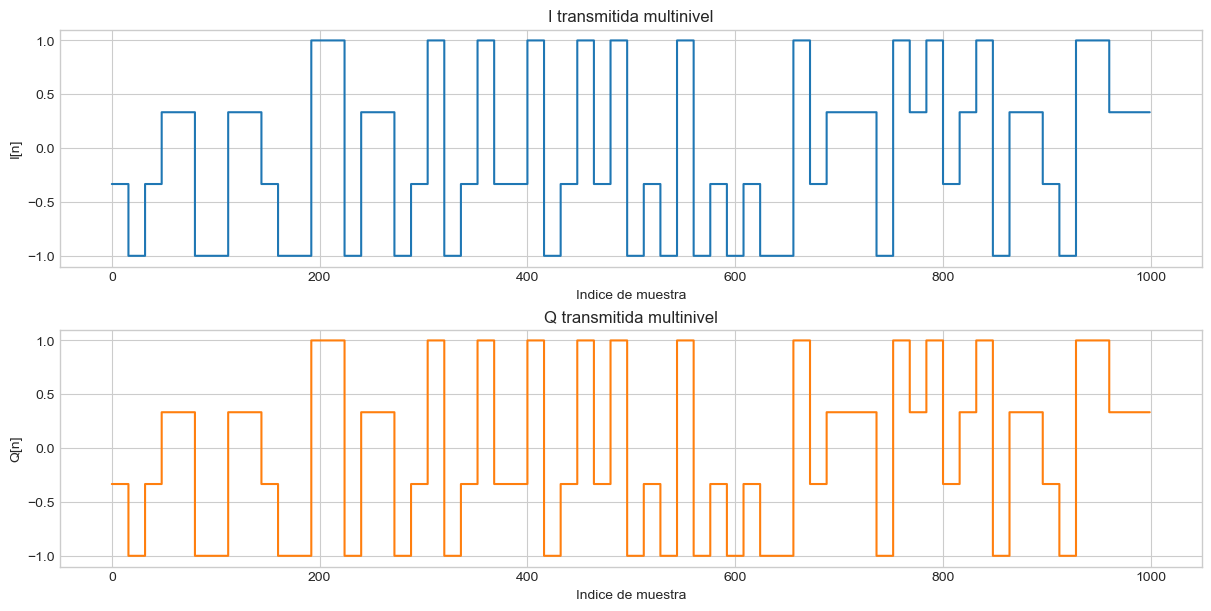

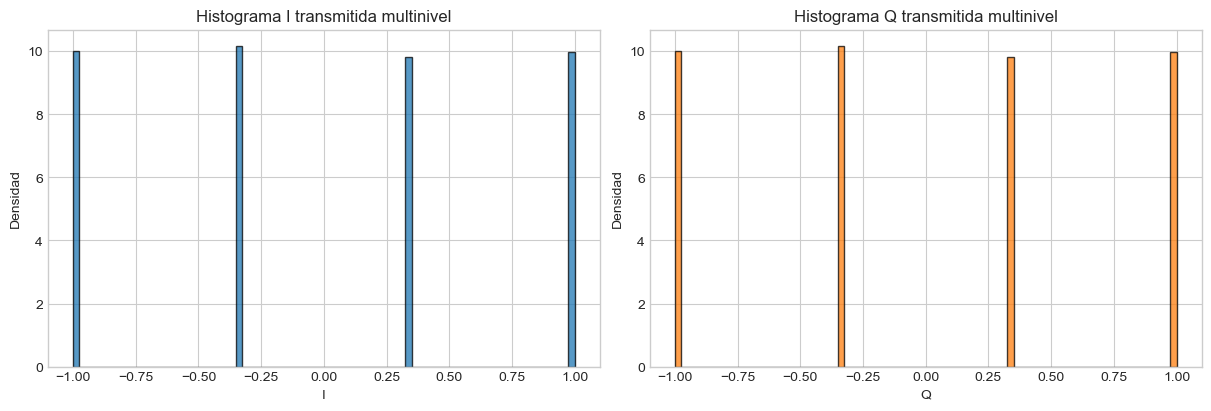

In [34]:
txMulti_I = np.real(txSignal_multilevel)
txMulti_Q = np.imag(txSignal_multilevel)

n_preview_multi = 1000
n_multi = np.arange(n_preview_multi)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].step(n_multi, txMulti_I[:n_preview_multi], where="post")
axes[0].set_title("I transmitida multinivel")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I[n]")
axes[0].grid(True)

axes[1].step(n_multi, txMulti_Q[:n_preview_multi], where="post", color="C1")
axes[1].set_title("Q transmitida multinivel")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q[n]")
axes[1].grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(txMulti_I, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma I transmitida multinivel")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(txMulti_Q, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma Q transmitida multinivel")
axes[1].set_xlabel("Q")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)
plt.show()

## 34. Transmision y recepcion multinivel

Como la senal transmitida cambia, destruimos el buffer de transmision, volvemos a configurar `tx_cyclic_buffer` y ajustamos `rx_buffer_size`. Esto sigue la advertencia de la consigna para evitar errores de configuracion o datos viejos en buffers.

In [35]:
sdr.tx_destroy_buffer()
sdr.tx_cyclic_buffer = tx_cyclic_buffer
sdr.rx_buffer_size = len(txSignal_multilevel)
sdr.tx_hardwaregain_chan0 = TxAtten_high_power

# ---- Transmitter
sdr.tx(txSignal_multilevel * (2**14))

# ---- Clear Rx buffer
for i in range(10):
    raw_data_multilevel = sdr.rx()

# ---- Receiver
rxSignal_multilevel = sdr.rx()

print("TxAtten usado:", sdr.tx_hardwaregain_chan0)
print("RxBufferSize configurado:", sdr.rx_buffer_size)
print("Longitud de txSignal_multilevel:", len(txSignal_multilevel))
print("Longitud de rxSignal_multilevel:", len(rxSignal_multilevel))
print("Primeras 10 muestras recibidas:")
print(rxSignal_multilevel[:10])

TxAtten usado: -70
RxBufferSize configurado: 262144
Longitud de txSignal_multilevel: 262144
Longitud de rxSignal_multilevel: 262144
Primeras 10 muestras recibidas:
[62. -4.j 48.-28.j 41.-38.j 54.-16.j 40. -9.j 62.-16.j 57.-34.j 58.-42.j
 51.-32.j 51.-36.j]


## 35. Normalizacion de la senal multinivel recibida

Normalizamos la potencia promedio a 1 para analizar la forma de los histogramas sin depender de la escala absoluta recibida.

In [36]:
rxPower_multilevel = np.mean(np.abs(rxSignal_multilevel)**2)
rxSignalMultilevelNorm = rxSignal_multilevel / np.sqrt(rxPower_multilevel)

rxMulti_I = np.real(rxSignalMultilevelNorm)
rxMulti_Q = np.imag(rxSignalMultilevelNorm)

print("Potencia antes de normalizar:", rxPower_multilevel)
print("Potencia despues de normalizar:", np.mean(np.abs(rxSignalMultilevelNorm)**2))

Potencia antes de normalizar: 1986.1641845703125
Potencia despues de normalizar: 0.9999999999999999


## 36. Grafica temporal e histograma de la senal multinivel recibida

La consigna pide mostrar el histograma de la senal recibida. Tambien graficamos una porcion temporal para tener contexto visual.

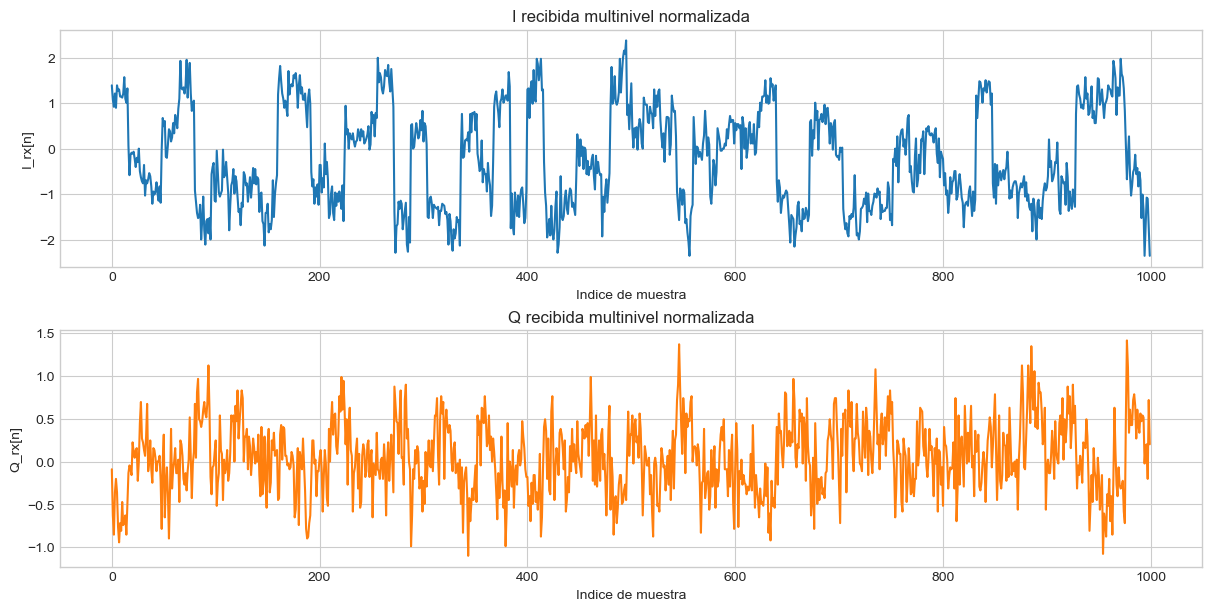

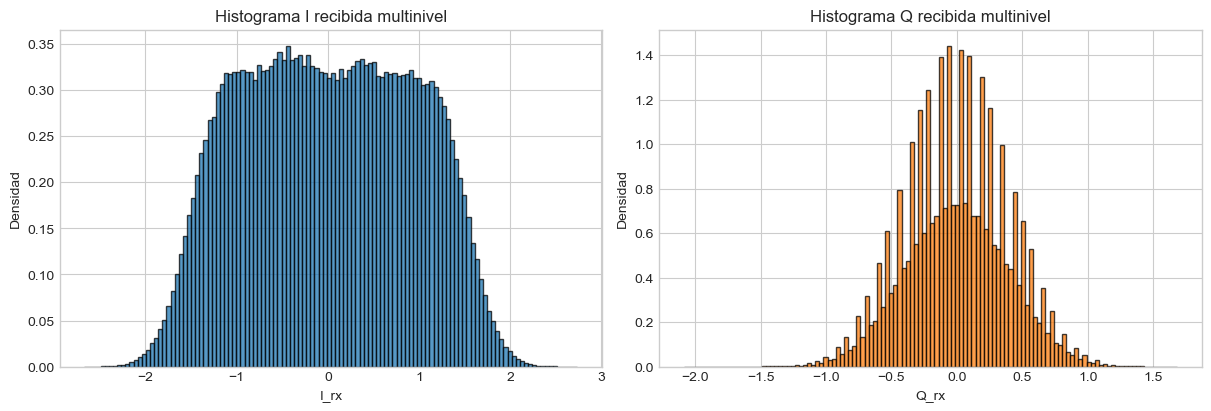

Media I recibida multinivel: 0.0019489309928828204
Media Q recibida multinivel: -0.0015550190762748536
Varianza I recibida multinivel: 0.8533638411093423
Varianza Q recibida multinivel: 0.14662994247431488


In [37]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].plot(n_multi, rxMulti_I[:n_preview_multi])
axes[0].set_title("I recibida multinivel normalizada")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_rx[n]")
axes[0].grid(True)

axes[1].plot(n_multi, rxMulti_Q[:n_preview_multi], color="C1")
axes[1].set_title("Q recibida multinivel normalizada")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_rx[n]")
axes[1].grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(rxMulti_I, bins=120, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma I recibida multinivel")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rxMulti_Q, bins=120, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma Q recibida multinivel")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)
plt.show()

print("Media I recibida multinivel:", np.mean(rxMulti_I))
print("Media Q recibida multinivel:", np.mean(rxMulti_Q))
print("Varianza I recibida multinivel:", np.var(rxMulti_I))
print("Varianza Q recibida multinivel:", np.var(rxMulti_Q))

## 37. Conclusion del punto 6

Completar despues de ejecutar:

- La senal transmitida contiene cuatro niveles equiprobables: `-1`, `-0.3333`, `+0.3333` y `+1`.
- En el histograma transmitido se ven cuatro concentraciones con pesos similares.
- En el histograma recibido, esos niveles pueden aparecer ensanchados por el ruido y por los efectos del canal/SDR.
- Si la recepcion es buena, deberian distinguirse cuatro grupos o regiones. Si el ruido es alto, los niveles interiores `-0.3333` y `+0.3333` pueden mezclarse mas facilmente porque estan mas cerca entre si.
- Este punto muestra que al aumentar la cantidad de niveles se transmite mas informacion por simbolo, pero tambien se vuelve mas dificil distinguir correctamente las hipotesis en presencia de ruido.

In [38]:
# Since it is not possible to turn off Tx, it is configured to transmit at low power and on a different frequency than Rx.
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = -89 
sdr.tx_lo                 = int(2400e6)
sdr.rx_lo                 = int(950e6)
sdr.tx(np.zeros(2048))

In [39]:
del(sdr)